In [1]:
%cd ..

/home/yujin109/airfoil-completion


/home/yujin109/airfoil-completion/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os

import numpy as np
import torch
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.data import AirfoilDataset
from src.diffusion import Diffuser
from src.xfoil_utils import get_cl

100%|██████████| 8/8 [00:04<00:00,  1.77it/s]


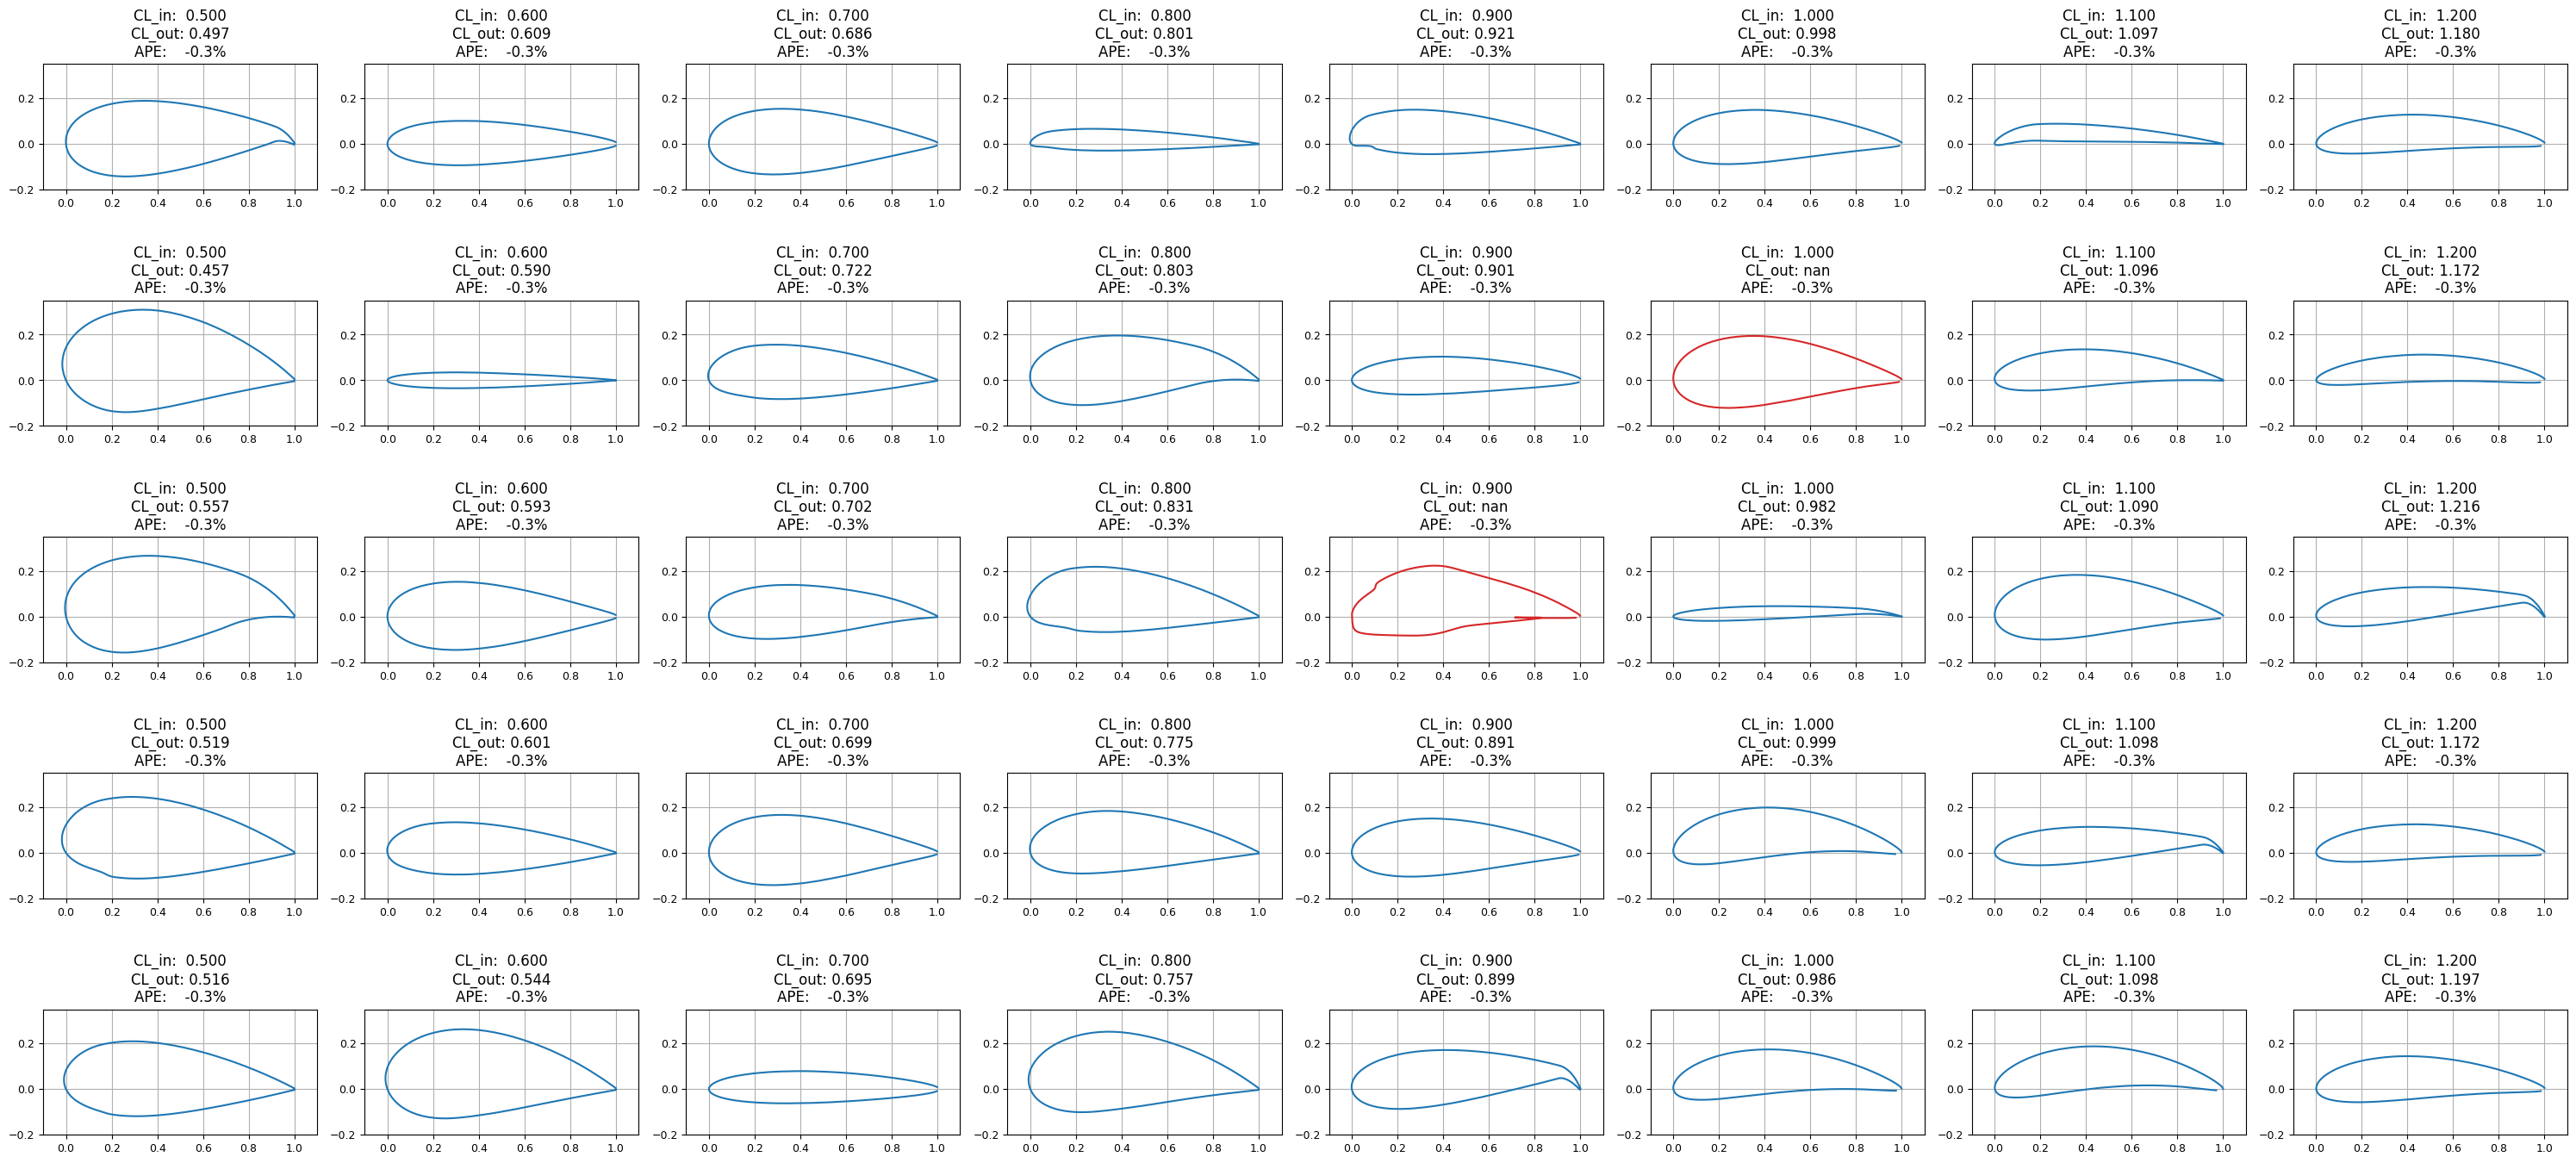

In [ ]:
save_npz = np.load(
    "/home/yujin109/airfoil-completion/results/250426-001:CFG(0)+pos-enc+beta_end0.05/samples/final_2505040216_generated_data_for_plot.npz"
)
cls_conditioned_array = save_npz["cls_conditioned"]
coords_generated_array = save_npz["coords_generated"]

num_variation_of_cl = cls_conditioned_array.shape[0]
num_samples_for_each_cl = cls_conditioned_array.shape[1]

dataset = AirfoilDataset(normalize=True)

fig, axs = plt.subplots(num_samples_for_each_cl, num_variation_of_cl, figsize=(30, 14))

for col in tqdm(range(num_variation_of_cl), total=num_variation_of_cl):
    cond = cls_conditioned_array[col]
    generated = coords_generated_array[col]
    for row in range(num_samples_for_each_cl):
        sample = torch.tensor(generated[row])
        sample_denorm = dataset.denormalize_coord(sample).numpy()
        x_coord = sample_denorm[0, :]
        y_coord = sample_denorm[1, :]
        try:
            cl_eval = get_cl(sample_denorm, angle=5)
        except Exception:
            cl_eval = np.nan
        if np.isnan(cl_eval):
            cl_ape = np.nan
            color = "tab:red"
        else:
            cl_ape = np.abs((cl_eval-cond[0])/cond[0]*100)
            color = "tab:blue"
        axs[row, col].plot(x_coord, y_coord, color=color)
        axs[row, col].set_title(f"CL_in:  {cond[0]:.3f}\nCL_out: {cl_eval:.3f}\nAPE:    {cl_ape:.1f}%", fontsize=12)
        axs[row, col].set_aspect("equal", "box")
        # 軸の表示範囲を固定
        axs[row, col].set_xlim(-0.1, 1.1)
        axs[row, col].set_ylim(-0.2, 0.35)
        axs[row, col].tick_params(labelsize=9)
        axs[row, col].grid(True)
plt.tight_layout()
plt.show()

In [33]:
cls_conditioned_array[0]

array([0.5, 0.5, 0.5, 0.5, 0.5])

In [9]:
len(cls_conditioned_array.tolist())

8

In [7]:
coords_generated_array

array([[[[ 4.75231856e-01,  5.33749759e-01,  5.87827563e-01, ...,
           1.72648346e+00,  2.23388577e+00,  1.87250704e-01],
         [ 6.77283645e-01,  7.13845074e-01,  7.43562996e-01, ...,
          -5.08674979e-01, -4.41344440e-01, -7.81034172e-01]],

        [[ 5.85358262e-01,  6.30821407e-01,  6.68208778e-01, ...,
           1.18942416e+00,  1.42218280e+00,  1.22412778e-01],
         [ 4.53751720e-02,  9.03715715e-02,  1.24538489e-01, ...,
           6.06858321e-02,  2.20959723e-01, -7.73914695e-01]],

        [[ 4.89108652e-01,  5.51140904e-01,  6.02491558e-01, ...,
           1.62887275e+00,  2.06412745e+00,  2.00020924e-01],
         [ 2.69036740e-01,  3.18028867e-01,  3.54391277e-01, ...,
          -1.41149774e-01, -1.49722667e-02, -7.85552740e-01]],

        [[ 6.74859822e-01,  7.13053167e-01,  7.43096471e-01, ...,
           7.14446962e-01,  6.51475072e-01,  1.60859331e-01],
         [ 3.34198505e-01,  3.55301023e-01,  3.81154656e-01, ...,
          -2.34295651e-01, -8.88